# Set Covering Problem — Constructive Heuristics
### Exercise 1.1 — CH1, CH2, CH3, redundancy elimination and experiments

This notebook implements the three constructive heuristics, keeps the solution state **incremental**, applies redundancy elimination (RE), and reports the two required performance measures.

### The notebook covers:

1. Implementation **CH1, CH2 and CH3** to construct a feasible set cover.
2. Never add a redundant set during construction: every selected set must cover at least one element that is still uncovered.
3. Maintain the evaluation function and partial-solution status incrementally (covered elements, cover counts, candidate gains and cost).
4. Apply each heuristic once per instance, with and without RE, using the same random seed for randomized steps.
5. Report the **average percentage deviation from the best-known solution (BKS)** and the **fraction of instances improved by RE**.

The notebook also contains a small incremental-state self-test and an optional comparison of RE removal orders.

## 1. Imports and configuration

`DATA_DIR` is relative to the notebook's current working directory. The data is in the `SCP-Instances/`, in the same directory.

In [44]:
import heapq
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("SCP-Instances")
SEED = 42


## 2. OR-Library SCP format

Each instance has the form

```text
m n
c_1 ... c_n
k_1 <k_1 column indices>
...
k_m <k_m column indices>
```

Here `m` is the number of elements (rows) and `n` is the number of available sets (columns). The file uses **1-based** column indices; the implementation converts them to **0-based** indices.

In [45]:
def read_scp_instance(filepath):
    """Read one SCP instance in OR-Library format.

    Format:
        m n
        c_1 ... c_n
        k_1 <k_1 column indices (1-based)>
        ...
        k_m <k_m column indices (1-based)>

    Returns dict containing m, n, costs array, rows list, and cols list.
    """
    filepath = Path(filepath)
    tokens = filepath.read_text().split()
    if len(tokens) < 2:
        raise ValueError(f"{filepath}: file is too short to contain m and n")

    values = [int(x) for x in tokens]
    idx = 0
    m, n = values[idx], values[idx + 1]
    idx += 2

    if m <= 0 or n <= 0:
        raise ValueError(f"{filepath}: invalid dimensions m={m}, n={n}")

    costs = np.asarray(values[idx : idx + n], dtype=float)
    idx += n

    rows = []
    for e in range(m):
        k = values[idx]
        idx += 1
        covering = [c - 1 for c in values[idx : idx + k]]  # Convert to 0-based
        idx += k
        rows.append(covering)

    cols = [[] for _ in range(n)]
    for e, covering in enumerate(rows):
        for j in covering:
            cols[j].append(e)

    return {"m": m, "n": n, "costs": costs, "rows": rows, "cols": cols}


## 3. Incremental solution state

The central idea is to avoid repeatedly recomputing coverage from scratch. For a partial solution we maintain:

| State | Meaning | Update/query | 
|---|---|---|
| `chosen[j]` | set `j` is selected | O(1) lookup | 
| `cover_count[e]` | number of selected sets covering element `e` | updated only when a set is added/removed | 
| `uncovered` + `_pos` | current uncovered elements | O(1) swap-remove/append | 
| `gain[j]` | number of currently uncovered elements that set `j` would cover | maintained incrementally | 
| `solution_cost` | total cost of selected sets | O(1) update | 

The key candidate condition is `gain[j] > 0`. Therefore a redundant set (`gain == 0`) is never selected during construction.

When an element changes from uncovered to covered, every set containing that element loses one unit of gain. During RE, the reverse update restores that gain if the element becomes uncovered again.

In [46]:
class SCPInstance:
    """Maintains incremental solution state for Set Covering Problem.

    State variables maintained in O(1) / O(k):
    - chosen: boolean mask of selected sets
    - cover_count: number of selected sets covering element e
    - gain: number of uncovered elements covered by set j
    - uncovered & _pos: O(1) list for fast sampling and state maintenance
    - solution_cost: total cost of currently chosen sets
    """

    def __init__(self, data, name=None):
        self.name = name
        self.m, self.n = data["m"], data["n"]
        self.costs = np.asarray(data["costs"], dtype=float)
        self.rows = data["rows"] # element -> covering sets (lists)
        self.cols = data["cols"]  # set -> covered elements (lists)
        self.rows_np = [np.asarray(r, dtype=np.int64) for r in self.rows]
        self.cols_np = [np.asarray(c, dtype=np.int64) for c in self.cols]
        self.col_size = np.asarray([len(c) for c in self.cols], dtype=np.int64)
        self.reset()

    # ---------------------------------------------------------------- state
    def reset(self):
        self.chosen = np.zeros(self.n, dtype=bool)
        self.cover_count = np.zeros(self.m, dtype=np.int64)
        self.gain = self.col_size.copy()    # nothing covered yet -> gain = column size
        self.uncovered = list(range(self.m))  # list of uncovered elements
        self._pos = np.arange(self.m, dtype=np.int64) # position of each element inside `uncovered`
        self.solution_cost = 0.0

    def snapshot(self):
        """Return a deep copy snapshot of current state."""
        return {
            "chosen": self.chosen.copy(),
            "cover_count": self.cover_count.copy(),
            "gain": self.gain.copy(),
            "uncovered": self.uncovered.copy(),
            "_pos": self._pos.copy(),
            "solution_cost": float(self.solution_cost),
        }

    def restore(self, state):
        """Restore instance state from a snapshot."""
        self.chosen = state["chosen"].copy()
        self.cover_count = state["cover_count"].copy()
        self.gain = state["gain"].copy()
        self.uncovered = state["uncovered"].copy()
        self._pos = state["_pos"].copy()
        self.solution_cost = float(state["solution_cost"])

    def is_complete_cover(self):
        return len(self.uncovered) == 0

    def solution_sets(self):
        return np.flatnonzero(self.chosen).tolist()
    
    # ------------------------------------------------ O(1) uncovered-list ops
    def _mark_covered(self, e):
        pos = int(self._pos[e])
        last = self.uncovered.pop()
        if last != e:
            self.uncovered[pos] = last
            self._pos[last] = pos
        self.gain[self.rows_np[e]] -= 1

    def _mark_uncovered(self, e):
        self._pos[e] = len(self.uncovered)
        self.uncovered.append(e)
        self.gain[self.rows_np[e]] += 1

    # ------------------------------------------------------------ mutations
    def add_set(self, j):
        j = int(j)
        if self.chosen[j]:
            return 0
        self.chosen[j] = True
        self.solution_cost += self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] += 1
        newly_covered = els[self.cover_count[els] == 1]
        for e in newly_covered:
            self._mark_covered(int(e))
        return len(newly_covered)

    def remove_set(self, j):
        j = int(j)
        if not self.chosen[j]:
            return 0
        self.chosen[j] = False
        self.solution_cost -= self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] -= 1
        newly_uncovered = els[self.cover_count[els] == 0]
        for e in newly_uncovered:
            self._mark_uncovered(int(e))
        return len(newly_uncovered)
    
    # -------------------------------------------------------------- queries
    def is_removable(self, j):
        """A set is removable if all its covered elements are covered by >= 2 sets."""
        return bool(np.all(self.cover_count[self.cols_np[int(j)]] > 1))
    
    # -------------------------------------------------------- verification
    def check_solution(self):
        """Verify feasibility and cost correctness."""
        covered = np.zeros(self.m, dtype=bool)
        for j in np.flatnonzero(self.chosen):
            covered[self.cols_np[j]] = True
        if not covered.all():
            raise AssertionError(f"{self.name}: incomplete set cover")
        if not np.isclose(self.solution_cost, self.costs[self.chosen].sum()):
            raise AssertionError(f"{self.name}: cost mismatch")

## 4. Instance loading and best-known solutions

The filename convention used here maps names such as `scp42.txt` to instance label `4.2`, and `scpA3.txt` to `A.3`. Duplicate labels are rejected rather than silently overwritten.

The Best Known Solution (BKS) dictionary is kept separate from the heuristic code so that the percentage-deviation calculation is easy to audit.

In [47]:
FNAME_RE = re.compile(r"scp([A-Za-z]|\d)(\d+)", re.IGNORECASE)

def label_from_filename(path):
    match = FNAME_RE.search(Path(path).name)
    if not match:
        return None
    group, num = match.groups()
    return f"{group.upper()}.{num}"

def sort_key(label):
    cls, num = label.split(".")
    return (cls, int(num))

def load_all_instances(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        return {}

    instances = {}
    for path in sorted(data_dir.iterdir()):
        if not path.is_file():
            continue
        label = label_from_filename(path)
        if label is None:
            continue
        if label in instances:
            raise ValueError(f"Duplicate instance label {label!r}: multiple files match it")
        instances[label] = SCPInstance(read_scp_instance(path), name=label)

    return dict(sorted(instances.items(), key=lambda kv: sort_key(kv[0])))

BKS = {
    "4.1": 429, "4.2": 512, "4.3": 516, "4.4": 494, "4.5": 512,
    "4.6": 560, "4.7": 430, "4.8": 492, "4.9": 641, "4.10": 514,
    "5.1": 253, "5.2": 302, "5.3": 226, "5.4": 242, "5.5": 211,
    "5.6": 213, "5.7": 293, "5.8": 288, "5.9": 279, "5.10": 265,
    "6.1": 138, "6.2": 146, "6.3": 145, "6.4": 131, "6.5": 161,
    "A.1": 253, "A.2": 252, "A.3": 232, "A.4": 234, "A.5": 236,
    "B.1": 69,  "B.2": 76,  "B.3": 80,  "B.4": 79,  "B.5": 72,
    "C.1": 227, "C.2": 219, "C.3": 243, "C.4": 219, "C.5": 215,
    "D.1": 60, "D.2": 66, "D.3": 72, "D.4": 62, "D.5": 61,
}

instances = load_all_instances(DATA_DIR)
if not instances:
    print(f"No SCP instances found in {DATA_DIR.resolve()}. Add the Moodle files and rerun this section.")
else:
    missing_bks = sorted(set(instances) - set(BKS), key=sort_key)
    if missing_bks:
        raise ValueError(f"Missing BKS values for: {missing_bks}")
    print(f"Loaded {len(instances)} instance(s): {list(instances)}")


Loaded 42 instance(s): ['4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5.1', '5.2', '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6.1', '6.2', '6.3', '6.4', '6.5', 'A.1', 'A.2', 'A.3', 'A.4', 'A.5', 'B.1', 'B.2', 'B.3', 'B.4', 'B.5', 'C.1', 'C.2', 'C.3', 'C.4', 'C.5', 'D.1', 'D.2', 'D.3', 'D.4', 'D.5']


## 5. Constructive heuristics

### CH1 — random constructive heuristic

Repeatedly choose a random uncovered element, then randomly choose one of the sets that covers it. Because the chosen set necessarily covers the selected uncovered element, it always has positive gain and is therefore non-redundant at the moment of insertion.

### CH2 — dynamic cost/gain greedy heuristic

For every candidate set use the score

$$
\text{score}(j)=\frac{c_j}{\text{gain}(j)},
$$

where `c(j)` is the set cost and  `gain(j)` is the number of currently uncovered elements covered by set `j`. Select the candidate with minimum score. The score is dynamic because the gain changes as the cover grows.

Thus, CH2 favors sets that provide a large amount of new coverage relative to their cost. Because gain is updated incrementally whenever an element becomes covered, the ratio reflects the current partial solution.

### CH3 — regret-based constructive heuristic

For each element `e`, define static regret as

$$
R_e = c_{(2),e}-c_{(1),e},
$$

where the two costs are the cheapest and second-cheapest sets covering `e`. High regret means that failing to use the cheapest option leaves a comparatively expensive fallback. Elements are considered from highest to lowest regret; for a still-uncovered element, choose the covering set with the best current cost/gain ratio.

Regret is computed once because the set of columns capable of covering a specific element does not change. If that element is still uncovered, none of those covering columns can already be selected.

In [48]:
def ch1_random(inst, seed=SEED):
    """CH1: random uncovered element + random set covering it."""
    rnd = random.Random(seed)
    inst.reset()
    while not inst.is_complete_cover():
        e = rnd.choice(inst.uncovered)
        j = rnd.choice(inst.rows[e])
        inst.add_set(j)
    return inst.solution_cost


def ch2_greedy(inst):
    """CH2: dynamic minimum cost/gain, implemented with a lazy heap."""
    inst.reset()
    costs = inst.costs

    heap = [
        (float(costs[j] / inst.gain[j]), j)
        for j in range(inst.n)
        if inst.gain[j] > 0
    ]
    heapq.heapify(heap)

    while not inst.is_complete_cover():
        # Lazy deletion: heap entries become stale when a set's gain changes.
        while heap:
            ratio, j = heapq.heappop(heap)
            if inst.chosen[j] or inst.gain[j] <= 0:
                continue
            current_ratio = float(costs[j] / inst.gain[j])
            if ratio == current_ratio:
                break
        else:
            raise RuntimeError(f"{inst.name}: no positive-gain candidate remains")

        # These elements are the only ones whose coverage/gain will change.
        els = inst.cols_np[j]
        newly_covered = els[inst.cover_count[els] == 0]
        inst.add_set(j)

        # Every set containing a newly covered element has had its gain reduced.
        touched = set()
        for e in newly_covered:
            touched.update(int(s) for s in inst.rows_np[int(e)])

        for s in touched:
            if not inst.chosen[s] and inst.gain[s] > 0:
                heapq.heappush(heap, (float(costs[s] / inst.gain[s]), s))

    return inst.solution_cost


def compute_regret(inst):
    """Return one static regret value per element."""
    regret = np.empty(inst.m, dtype=float)
    for e, covering_sets in enumerate(inst.rows_np):
        costs = inst.costs[covering_sets]
        if len(costs) < 2:
            regret[e] = np.inf
        else:
            two_smallest = np.partition(costs, 1)[:2]
            regret[e] = float(two_smallest[1] - two_smallest[0])
    return regret


def ch3_regret(inst, regret=None):
    """CH3: process elements by decreasing regret; choose best current cost/gain set."""
    if regret is None:
        regret = compute_regret(inst)

    inst.reset()
    order = np.argsort(-regret, kind="stable")
    for e in order:
        if inst.cover_count[e] > 0:
            continue
        cand = inst.rows_np[e]
        scores = inst.costs[cand] / inst.gain[cand]
        j = cand[int(np.argmin(scores))]
        inst.add_set(j)

    return inst.solution_cost


HEURISTICS = {
    "CH1 (random)": ch1_random,
    "CH2 (cost/gain)": ch2_greedy,
    "CH3 (regret)": ch3_regret,
}


## 6. Redundancy elimination (RE)

A selected set is redundant when **every** element it covers has at least one other selected cover. Because removing a set can only decrease cover counts, a set that is not removable at the moment it is tested will not become removable later in the same pass. The scan therefore needs only one pass in the chosen order.

The assignment requires RE; `cost_desc` is used for the headline results. The two other orders are retained as an optional sensitivity analysis.

In [49]:
RE_ORDERS = ["cost_desc", "random", "cost_per_element"]

def redundancy_elimination(inst, order="cost_desc", seed=SEED):
    """Remove redundant selected sets once, in the requested order."""
    if not inst.is_complete_cover():
        raise ValueError("RE must start from a complete cover")

    sets = inst.solution_sets()
    if order == "cost_desc":
        sets.sort(key=lambda j: (-inst.costs[j], j))
    elif order == "random":
        random.Random(seed).shuffle(sets)
    elif order == "cost_per_element":
        sets.sort(
            key=lambda j: (
                -(inst.costs[j] / len(inst.cols_np[j]) if len(inst.cols_np[j]) else np.inf),
                j,
            )
        )
    else:
        raise ValueError(f"Unknown RE order: {order}")

    for j in sets:
        if inst.is_removable(j):
            inst.remove_set(j)

    return inst.solution_cost


## 7. Experiments

For each instance and each heuristic:

1. construct one solution and verify it is a complete cover;
2. save the complete incremental state;
3. restore that **same state** before every RE order so all RE comparisons start from exactly the same solution;
4. record the cost, number of selected sets and runtime.



In [50]:
def pct_dev(cost, bks):
    """Percentage deviation from BKS: 100 * (cost - BKS) / BKS."""
    with np.errstate(divide="ignore", invalid="ignore"):
        return 100.0 * (cost - bks) / bks


def run_experiments(instances, bks_dict):
    records = []
    for label, inst in instances.items():
        if label not in bks_dict:
            raise ValueError(f"No BKS value supplied for instance {label}")
        bks = bks_dict[label]
        precomputed_regret = compute_regret(inst)

        for method, construct in HEURISTICS.items():
            t0 = time.perf_counter()
            if method == "CH1 (random)":
                cost_no_re = construct(inst, seed=SEED)
            elif method == "CH3 (regret)":
                cost_no_re = construct(inst, regret=precomputed_regret)
            else:
                cost_no_re = construct(inst)
            t_construct = time.perf_counter() - t0
            inst.check_solution()

            snapshot = inst.snapshot()
            rec = {
                "instance": label,
                "class": label.split(".")[0],
                "method": method,
                "bks": float(bks),
                "cost_no_re": float(cost_no_re),
                "n_sets_no_re": int(np.count_nonzero(inst.chosen)),
                "t_construct": t_construct,
            }

            for order in RE_ORDERS:
                inst.restore(snapshot)
                t0 = time.perf_counter()
                cost_re = redundancy_elimination(inst, order=order, seed=SEED)
                t_re = time.perf_counter() - t0
                inst.check_solution()
                rec[f"cost_re_{order}"] = float(cost_re)
                rec[f"t_re_{order}"] = t_re
                rec[f"n_sets_re_{order}"] = int(np.count_nonzero(inst.chosen))

            records.append(rec)

    df = pd.DataFrame(records)
    df["cost_re"] = df["cost_re_cost_desc"]
    df["t_re"] = df["t_re_cost_desc"]
    df["n_sets_re"] = df["n_sets_re_cost_desc"]
    df["dev_no_re"] = pct_dev(df["cost_no_re"], df["bks"])
    df["dev_re"] = pct_dev(df["cost_re"], df["bks"])

    for order in RE_ORDERS:
        df[f"dev_re_{order}"] = pct_dev(df[f"cost_re_{order}"], df["bks"])
        df[f"improved_{order}"] = df[f"cost_re_{order}"] < df["cost_no_re"]

    df["improved"] = df["improved_cost_desc"]
    return df


if instances:
    results = run_experiments(instances, BKS)
    print(f"Experiment rows: {len(results)} = {len(instances)} instances x {len(HEURISTICS)} heuristics")
else:
    results = pd.DataFrame()
    print("Real experiment skipped: no SCP instance files were found.")


Experiment rows: 126 = 42 instances x 3 heuristics


## 8. Assignment results

The headline tables below correspond directly to the two requested measures. Percentage deviation is

$$
\text{Dev}(\%) = 100\,\frac{\text{heuristic cost} - \text{BKS}}{\text{BKS}}.
$$

A solution **profits from RE** only when RE strictly decreases its cost. Ties are not counted as improvements.

In [51]:
METHOD_ORDER = list(HEURISTICS)
CLASS_ORDER = [c for c in ["4", "5", "6", "A", "B", "C", "D"] if c in set(results.get("class", []))]

def overall_table(df):
    if df.empty:
        return pd.DataFrame()
    g = df.groupby("method", sort=False)
    out = pd.DataFrame({
        "avg dev % (no RE)": g["dev_no_re"].mean(),
        "avg dev % (with RE)": g["dev_re"].mean(),
        "improved by RE": g["improved"].sum().astype(int),
        "fraction improved": g["improved"].mean(),
        "avg cost saved by RE": (df["cost_no_re"] - df["cost_re"]).groupby(df["method"]).mean(),
        "avg time construct (ms)": g["t_construct"].mean() * 1e3,
        "avg time RE (ms)": g["t_re"].mean() * 1e3,
    })
    out["improved by RE"] = out["improved by RE"].astype(str) + f" / {df['instance'].nunique()}"
    return out.loc[METHOD_ORDER]

if not results.empty:
    overall = overall_table(results)
    display(
        overall.style.format({
            "avg dev % (no RE)": "{:.2f}",
            "avg dev % (with RE)": "{:.2f}",
            "fraction improved": "{:.1%}",
            "avg cost saved by RE": "{:.1f}",
            "avg time construct (ms)": "{:.2f}",
            "avg time RE (ms)": "{:.3f}",
        })
    )
    print ("Done")
else:
    print("Run the experiments first to populate the headline table.")


,avg dev % (no RE),avg dev % (with RE),improved by RE,fraction improved,avg cost saved by RE,avg time construct (ms),avg time RE (ms)
method,,,,,,,
CH1 (random),2096.61,1592.64,42 / 42,100.0%,899.0,1.11,0.417
CH2 (cost/gain),13.62,5.52,42 / 42,100.0%,20.4,32.39,0.380
CH3 (regret),15.82,12.18,41 / 42,97.6%,7.4,1.19,0.270


Done


In [52]:
def class_table(df, value):
    table = df.pivot_table(index="class", columns="method", values=value, aggfunc="mean")
    return table.reindex(CLASS_ORDER)[METHOD_ORDER]

if not results.empty:
    print("Average percentage deviation from BKS — WITHOUT RE")
    display(class_table(results, "dev_no_re").round(2))

    print("Average percentage deviation from BKS — WITH RE")
    display(class_table(results, "dev_re").round(2))

    print("Fraction of instances improved by RE")
    display(class_table(results.assign(improved=results["improved"].astype(float)), "improved").round(3))


Average percentage deviation from BKS — WITHOUT RE


method,CH1 (random),CH2 (cost/gain),CH3 (regret)
class,,,
4,707.37,12.32,18.38
5,1515.54,12.53,14.39
6,1605.40,15.63,14.38
A,1893.22,15.31,11.65
B,3347.09,11.40,16.73
C,2361.10,14.15,17.07
D,4544.96,15.67,17.76


Average percentage deviation from BKS — WITH RE


method,CH1 (random),CH2 (cost/gain),CH3 (regret)
class,,,
4,538.50,3.93,15.82
5,1132.36,4.97,10.95
6,1188.23,8.08,11.28
A,1400.83,4.80,8.54
B,2583.64,4.03,12.24
C,1729.94,4.59,14.32
D,3575.71,9.66,10.88


Fraction of instances improved by RE


method,CH1 (random),CH2 (cost/gain),CH3 (regret)
class,,,
4,1.0,1.0,1.0
5,1.0,1.0,1.0
6,1.0,1.0,1.0
A,1.0,1.0,1.0
B,1.0,1.0,0.8
C,1.0,1.0,1.0
D,1.0,1.0,1.0


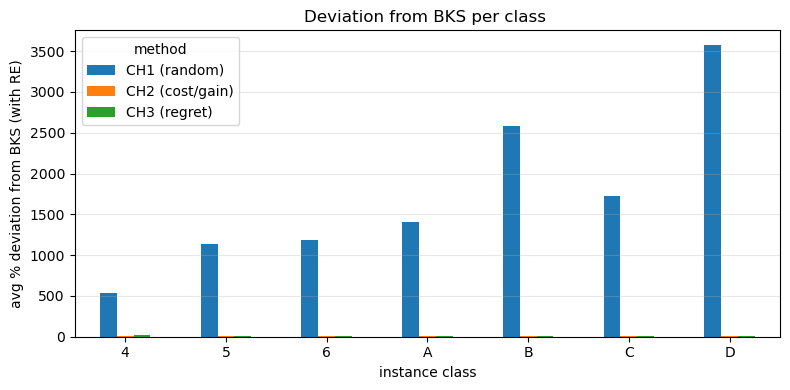

In [53]:
# Plot: average deviation after RE per class (CH1 is orders of magnitude worse, shown in the table instead)
plot_methods = [m for m in METHOD_ORDER ]
ct = class_table(results, "dev_re")[plot_methods]
ax = ct.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("avg % deviation from BKS (with RE)")
ax.set_xlabel("instance class")
ax.set_title("Deviation from BKS per class ")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

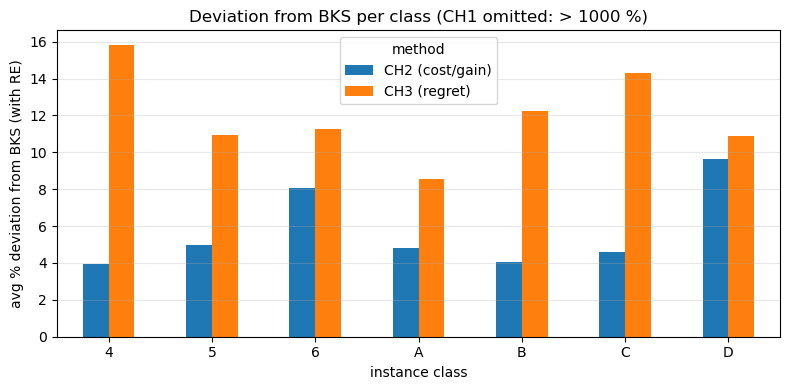

In [54]:
# Plot: average deviation after RE per class (CH1 is orders of magnitude worse, shown in the table instead)
plot_methods = [m for m in METHOD_ORDER if not m.startswith("CH1")]
ct = class_table(results, "dev_re")[plot_methods]
ax = ct.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_ylabel("avg % deviation from BKS (with RE)")
ax.set_xlabel("instance class")
ax.set_title("Deviation from BKS per class (CH1 omitted: > 1000 %)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 10. RE-order analysis

This section is useful for explaining why the order can affect the final cover. All orders start from the same saved solution state.

In [55]:
def re_order_table(df):
    rows = []
    for method, sub in df.groupby("method", sort=False):
        row = {"method": method, "avg dev % (no RE)": sub["dev_no_re"].mean()}
        for order in RE_ORDERS:
            row[f"dev % {order}"] = sub[f"dev_re_{order}"].mean()
            row[f"frac. improved {order}"] = sub[f"improved_{order}"].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("method").loc[METHOD_ORDER]


if not results.empty:
    re_cmp = re_order_table(results)
    display(
        re_cmp.style
        .format("{:.2f}", subset=[c for c in re_cmp.columns if c.startswith(("avg", "dev"))])
        .format("{:.1%}", subset=[c for c in re_cmp.columns if c.startswith("frac")])
    )


,avg dev % (no RE),dev % cost_desc,frac. improved cost_desc,dev % random,frac. improved random,dev % cost_per_element,frac. improved cost_per_element
method,,,,,,,
CH1 (random),2096.61,1592.64,100.0%,1626.77,100.0%,1594.60,100.0%
CH2 (cost/gain),13.62,5.52,100.0%,5.88,100.0%,5.57,100.0%
CH3 (regret),15.82,12.18,97.6%,12.21,97.6%,12.19,97.6%


In [56]:
if not results.empty:
    cols = [f"cost_re_{o}" for o in RE_ORDERS]
    best_cost = results[cols].min(axis=1)
    reaches_best = pd.DataFrame({
        order: results[f"cost_re_{order}"] == best_cost
        for order in RE_ORDERS
    })
    reaches_best["method"] = results["method"]
    display(
        reaches_best.groupby("method", sort=False).mean().loc[METHOD_ORDER]
        .style.format("{:.1%}")
        .set_caption("Share of instances where each RE order reaches the best RE cost from the same starting solution; ties count for all")
    )


,cost_desc,random,cost_per_element
method,,,
CH1 (random),73.8%,21.4%,61.9%
CH2 (cost/gain),92.9%,66.7%,90.5%
CH3 (regret),100.0%,95.2%,97.6%


## 11. Per-instance results and export

In [57]:
if not results.empty:
    detail_cols = [
        "instance", "method", "bks", "cost_no_re", "cost_re",
        "dev_no_re", "dev_re", "improved",
        "n_sets_no_re", "n_sets_re", "t_construct", "t_re",
    ]
    display(results[detail_cols].round(3))

    results.to_csv("scp_results.csv", index=False)

    summary = overall.reset_index()
    summary.to_csv("scp_overall_summary.csv", index=False)
    print("Saved scp_results.csv and scp_overall_summary.csv")
else:
    print("No files exported because the real experiment was skipped.")


,instance,method,bks,cost_no_re,cost_re,dev_no_re,dev_re,improved,n_sets_no_re,n_sets_re,t_construct,t_re
0,4.2,CH1 (random),512.0,4229.0,3247.0,725.977,534.180,True,90,69,0.002,0.001
1,4.2,CH2 (cost/gain),512.0,582.0,529.0,13.672,3.320,True,81,66,0.007,0.000
2,4.2,CH3 (regret),512.0,665.0,660.0,29.883,28.906,True,68,65,0.001,0.000
3,4.3,CH1 (random),516.0,4019.0,3174.0,678.876,515.116,True,82,66,0.001,0.000
4,4.3,CH2 (cost/gain),516.0,598.0,537.0,15.891,4.070,True,82,67,0.006,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...
121,D.4,CH2 (cost/gain),62.0,71.0,67.0,14.516,8.065,True,55,51,0.078,0.001
122,D.4,CH3 (regret),62.0,72.0,69.0,16.129,11.290,True,50,48,0.002,0.000
123,D.5,CH1 (random),61.0,2712.0,2384.0,4345.902,3808.197,True,56,48,0.005,0.001
124,D.5,CH2 (cost/gain),61.0,69.0,66.0,13.115,8.197,True,51,48,0.114,0.000


Saved scp_results.csv and scp_overall_summary.csv
